In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import transforms ,datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report  
)
from torchvision.datasets import ImageFolder
import seaborn as sns
import os
print(torch.__version__)
print(f"GPU: {torch.cuda.is_available()}")
from torch.cuda.amp import autocast, GradScaler

2.2.2+cu121
GPU: True


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Cihaz: {device}")

Cihaz: cuda


In [3]:
BATCH_SIZE = 32 # hər addımda 32 şəkil
LR = 0.001  # kiçik addımlarla öyrən 
NUM_EPOCHS = 30 #datasetin üzərindən 20 dəfə keç 
IMG_SIZE = 128  # şəkilləri 128×128 et
NUM_CLASSES = 101  # 101 yemək növü 

train_data  = ImageFolder(root='yemek_sekilleri/train')
val_data   = ImageFolder(root='yemek_sekilleri/validation')

print(len(train_data.classes))
print(len(val_data.classes))

print(train_data.classes)
print(val_data.classes)

print(len(train_data))
print(len(val_data))

101
101
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', '

In [4]:
temp_dataset = ImageFolder(root='yemek_sekilleri/train',transform=transforms.Compose([
    transforms.Resize((IMG_SIZE , IMG_SIZE)),
    transforms.ToTensor()
]))

temp_loader = DataLoader(
    temp_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4
)

r_mean, g_mean, b_mean = 0, 0, 0
r_std,  g_std,  b_std  = 0, 0, 0
total = len(temp_loader)

for images, _ in temp_loader:
    r_mean += images[:, 0, :, :].mean().item()
    g_mean += images[:, 1, :, :].mean().item()
    b_mean += images[:, 2, :, :].mean().item()
    r_std  += images[:, 0, :, :].std().item()
    g_std  += images[:, 1, :, :].std().item()
    b_std  += images[:, 2, :, :].std().item()

r_mean /= total; g_mean /= total; b_mean /= total
r_std  /= total; g_std  /= total; b_std  /= total

print(f"mean=[{r_mean:.4f}, {g_mean:.4f}, {b_mean:.4f}]")
print(f"std= [{r_std:.4f}, {g_std:.4f}, {b_std:.4f}]")

mean=[0.5459, 0.4445, 0.3444]
std= [0.2625, 0.2659, 0.2706]


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE , IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE , scale=(0.8 , 1.0)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5459, 0.4445, 0.3444] , std=[0.2625,  0.2659,  0.2706])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE , IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.5459, 0.4445, 0.3444], std=[0.2625, 0.2659, 0.2706])
])

# 32 batch size , 3 RGB kanal , 128 Height  , 128  Width

In [6]:
train_data = ImageFolder(root='yemek_sekilleri/train' , transform=train_transform)
val_data = ImageFolder(root='yemek_sekilleri/validation' , transform=val_transform)
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

images, labels = next(iter(train_loader))
print(f"Batch şəkil ölçüsü : {images.shape}")
print(f"Batch label ölçüsü : {labels.shape}")
print(f"Train batch sayı   : {len(train_loader)}")
print(f"Val batch sayı     : {len(val_loader)}")

Batch şəkil ölçüsü : torch.Size([32, 3, 128, 128])
Batch label ölçüsü : torch.Size([32])
Train batch sayı   : 2999
Val batch sayı     : 158


In [7]:
class FoodCNN(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.conv1_1 = nn.Conv2d(
            in_channels=3 ,
            out_channels=32 ,
            kernel_size=3 ,
            padding=1
        )

        self.conv1_2 = nn.Conv2d(
            in_channels=32 , 
            out_channels=64,
            kernel_size=3 , 
            padding=1
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=2 , 
            stride=2
        )

        self.bn1 = nn.BatchNorm2d(
            num_features=64
        )
        
        self.conv2_1 = nn.Conv2d(
            in_channels=64 , 
            out_channels=128 ,
            kernel_size=3 ,
            padding=1
        )

        self.conv2_2 = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=3,
            padding=1
        )
        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.bn2 =nn.BatchNorm2d(
            num_features=256
        )

        self.conv3_1 = nn.Conv2d(
            in_channels=256,
            out_channels=512,
            kernel_size=3,
            padding=1
        )

        self.conv3_2 = nn.Conv2d(
            in_channels=512,
            out_channels=512,
            kernel_size=3,
            padding=1
        )

        self.pool3 =nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
        self.bn3 = nn.BatchNorm2d(
            num_features=512
        )

        self.fc1 = nn.Linear(
            in_features=512 * 16 * 16,
            out_features=512
        )

        self.fc2 = nn.Linear(
            in_features=512,
            out_features=256
        )

        self.fc3 = nn.Linear(
            in_features=256, 
            out_features=NUM_CLASSES
        )
        self.dropout = nn.Dropout(p=0.4)
        
    def forward(self , x):
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = self.pool1(x)
        x = self.bn1(x)

        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x= self.pool2(x)
        x = self.bn2(x)

        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        x = self.pool3(x)
        x= self.bn3(x)

        x = torch.flatten(x , start_dim=1)

        x= F.relu(self.fc1(x))
        x= self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x 

model = FoodCNN().to(device)
print(model)
#! p.numel shapedeki butun 4 reqemin hamsini vurub toplayir bu butun qatlar ucun kecerlidir. 32 × 3 × 3 × 3 = 864 parametr =conv1_1: (32, 3, 3, 3)= 864
print(f"Parametr sayı: {sum(p.numel() for p in model.parameters()):,}")


FoodCNN(
  (conv1_1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3_1): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn3): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_runn

In [8]:
from collections import Counter
#* ('yemek_sekilleri/train/apple_pie/img1.jpg', 0),
#? ('yemek_sekilleri/train/apple_pie/img2.jpg', 0) = train_data.samples
labels = [label for _, label in train_data.samples]
counts = Counter(labels)
print(counts)
for cls_idx, count in list(counts.items())[:5]: # ! cls_idx=0, count=950  indexden taniyir hansi yemekdir.
    print(f"{train_data.classes[cls_idx]}: {count}")

Counter({0: 950, 1: 950, 2: 950, 3: 950, 4: 950, 5: 950, 6: 950, 7: 950, 8: 950, 9: 950, 10: 950, 11: 950, 12: 950, 13: 950, 14: 950, 15: 950, 16: 950, 17: 950, 18: 950, 19: 950, 20: 950, 21: 950, 22: 950, 23: 950, 24: 950, 25: 950, 26: 950, 27: 950, 28: 950, 29: 950, 30: 950, 31: 950, 32: 950, 33: 950, 34: 950, 35: 950, 36: 950, 37: 950, 38: 950, 39: 950, 40: 950, 41: 950, 42: 950, 43: 950, 44: 950, 45: 950, 46: 950, 47: 950, 48: 950, 49: 950, 50: 950, 51: 950, 52: 950, 53: 950, 54: 950, 55: 950, 56: 950, 57: 950, 58: 950, 59: 950, 60: 950, 61: 950, 62: 950, 63: 950, 64: 950, 65: 950, 66: 950, 67: 950, 68: 950, 69: 950, 70: 950, 71: 950, 72: 950, 73: 950, 74: 950, 75: 950, 76: 950, 77: 950, 78: 950, 79: 950, 80: 950, 81: 950, 82: 950, 83: 950, 84: 950, 85: 950, 86: 950, 87: 950, 88: 950, 89: 950, 90: 950, 91: 950, 92: 950, 93: 950, 94: 950, 95: 950, 96: 950, 97: 950, 98: 950, 99: 950, 100: 950})
apple_pie: 950
baby_back_ribs: 950
baklava: 950
beef_carpaccio: 950
beef_tartare: 950


In [9]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1, #? "100% əmin olma, 90% əmin ol" basga seyde ola biler tam emin olmasin.
    reduction='mean' #*  batch-ın ORTALAMA loss-u
)
optimizer = optim.Adam(
    params=model.parameters(),
    lr=LR, #! yeni_çəki = köhnə_çəki - lr × gradient
    weight_decay=1e-4, #! yeni_çəki = köhnə_çəki - lr × gradient - weight_decay × köhnə_çəki . Böyük çəkilər cəzalandırılır ,Model sadə qalır , Overfitting azalır Train zamanı bəzi çəkilər həddindən artıq böyüyür amma bu qoymur.
    betas=(0.9 , 0.999) #! 2ci: hər çəkinin addımını tənzimlə "aktiv olanı yavaşlat" passivi sürətləndir |||||| 1ci:istiqaməti sabitləşdir "sıçrama, düz get"
)

#! bunnan etdik olmadi oyrene bilmedi
# scheduler= optim.lr_scheduler.CosineAnnealingLR(
    #optimizer=optimizer,
    #T_max=NUM_EPOCHS,
    #eta_min=1e-6
#)
scheduler = optim.lr_scheduler.StepLR(
    optimizer=optimizer,
    step_size=7,
    gamma=0.5
)

print(f"Criterion : CrossEntropyLoss")
print(f"Optimizer : Adam (lr={LR}) ")
print(f"Scheduler : StepLR (step_size=7)")

Criterion : CrossEntropyLoss
Optimizer : Adam (lr=0.001) 
Scheduler : StepLR (step_size=7)


In [10]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0  # Bütün batch-ların loss cəmi
    correct      = 0    # Düzgün tanınan şəkillərin sayı
    total        = 0    # Ümumi şəkil sayı

    for inputs, targets in loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss    = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted  = outputs.max(1)
        total        += targets.size(0)
        correct      += (predicted == targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc  = correct / total * 100

    return epoch_loss, epoch_acc

In [ ]:
def val_one_epoch(model , loader , criterion):
    model.eval()
    running_loss = 0.0
    correct = 0 
    total = 0

    with torch.no_grad():
        for inputs , targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs , targets)
            running_loss+= loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total+= targets.size(0)
            correct += (predicted == targets).sum().item()
    epoch_loss = running_loss / total
    epoch_acc  = correct / total * 100
    return epoch_loss, epoch_acc

In [ ]:
best_val_acc = 0.0

train_losses = []
train_accs = []
val_losses = []
val_accs= []

for epoch in range(NUM_EPOCHS):
    train_loss , train_acc = train_one_epoch(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        loader=train_loader
    )

    val_loss , val_acc = val_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion
    )

    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  LR: {current_lr:.6f}")
    print("-" * 50)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Ən yaxşı model saxlandı! Val Acc: {val_acc:.2f}%")

Epoch [1/30]
  Train Loss: 4.6343 | Train Acc: 0.92%
  Val Loss:   4.6152 | Val Acc:   0.99%
  LR: 0.001000
--------------------------------------------------
Ən yaxşı model saxlandı! Val Acc: 0.99%
Epoch [2/30]
  Train Loss: 4.6171 | Train Acc: 0.95%
  Val Loss:   4.6152 | Val Acc:   0.99%
  LR: 0.001000
--------------------------------------------------
Epoch [3/30]
  Train Loss: 4.6049 | Train Acc: 1.19%
  Val Loss:   4.5340 | Val Acc:   2.04%
  LR: 0.001000
--------------------------------------------------
Ən yaxşı model saxlandı! Val Acc: 2.04%
Epoch [4/30]
  Train Loss: 4.5050 | Train Acc: 2.61%
  Val Loss:   4.3933 | Val Acc:   3.98%
  LR: 0.001000
--------------------------------------------------
Ən yaxşı model saxlandı! Val Acc: 3.98%
Epoch [5/30]
  Train Loss: 4.3547 | Train Acc: 4.62%
  Val Loss:   4.2090 | Val Acc:   6.91%
  LR: 0.001000
--------------------------------------------------
Ən yaxşı model saxlandı! Val Acc: 6.91%
Epoch [6/30]
  Train Loss: 4.2354 | Train Acc

In [ ]:
results_df = pd.DataFrame({
    'epoch':      range(1, NUM_EPOCHS+1),
    'train_loss': train_losses,
    'val_loss':   val_losses,
    'train_acc':  train_accs,
    'val_acc':    val_accs
})
results_df.to_csv('cnn_results.csv', index=False)

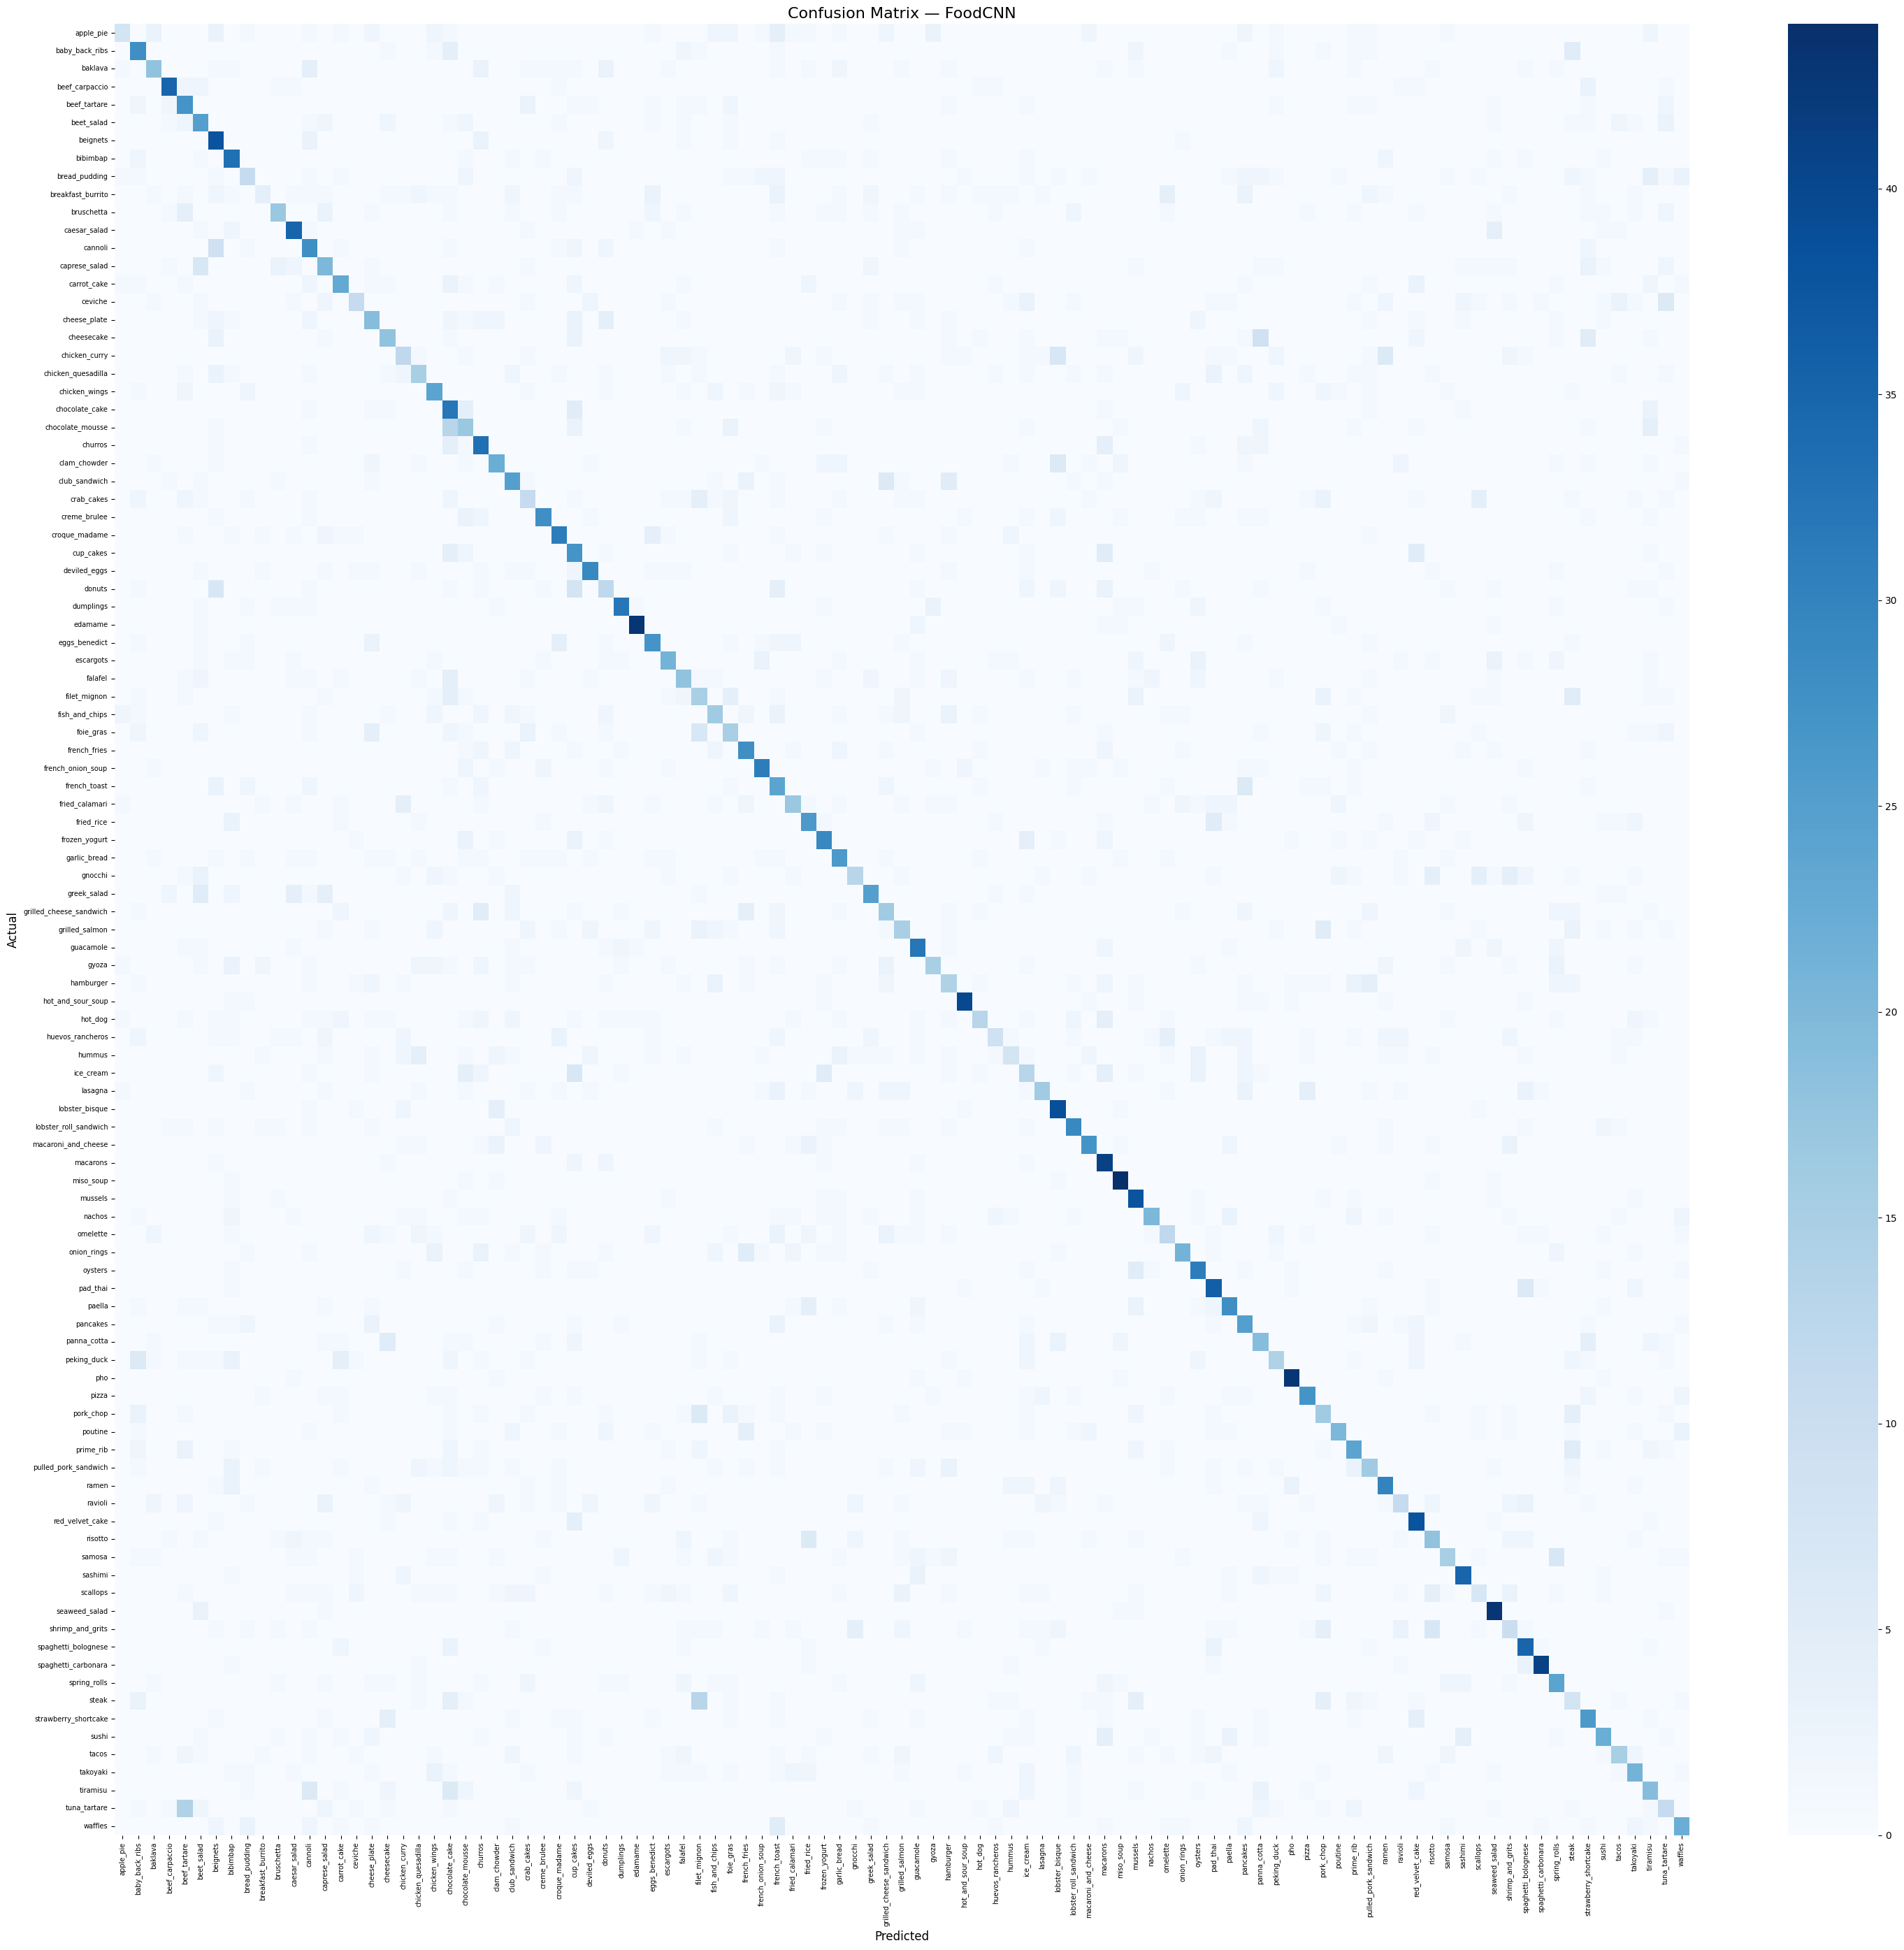

Confusion Matrix saxlandı 

Classification Report:
                         precision    recall  f1-score   support

              apple_pie       0.47      0.16      0.24        50
         baby_back_ribs       0.42      0.56      0.48        50
                baklava       0.51      0.36      0.42        50
         beef_carpaccio       0.76      0.70      0.73        50
           beef_tartare       0.36      0.54      0.44        50
             beet_salad       0.36      0.50      0.42        50
               beignets       0.42      0.76      0.54        50
               bibimbap       0.45      0.66      0.53        50
          bread_pudding       0.32      0.22      0.26        50
      breakfast_burrito       0.29      0.08      0.12        50
             bruschetta       0.57      0.34      0.42        50
           caesar_salad       0.59      0.70      0.64        50
                cannoli       0.35      0.56      0.43        50
          caprese_salad       0.36    

In [ ]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds   = []
all_targets = []

with torch.no_grad():
    for inputs, targets in val_loader:
        inputs  = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())   #![[76, 23, 45]] appendde netice bele cixir diye bunu etmirik onun yerine extend edirik onun neticesi ise: [12, 55, 88]

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(30, 28))
sns.heatmap(
    cm,
    annot=False,
    fmt='d',
    cmap='Blues',
    xticklabels=val_data.classes,
    yticklabels=val_data.classes
)
plt.title('Confusion Matrix — FoodCNN', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual',    fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    all_targets,
    all_preds,
    target_names=val_data.classes
))